In [1]:
import glob
import pandas as pd
from pathlib import Path
from pathlib import Path
import pandas as pd
import plotly.express as px
import numpy as np


single = ["aug-cc-pVDZ", "aug-cc-pVTZ", "aug-cc-pVQZ"]
#single_polarized = ["aug-cc-pCVDZ", "aug-cc-pCVTZ", "aug-cc-pCVQZ"]
double = [
    "d-aug-cc-pVDZ",
    "d-aug-cc-pVTZ",
    "d-aug-cc-pVQZ",
]
all_beta_data = None

mra_mol = None
basis_mol = None
double_polarized = ["d-aug-cc-pCVDZ", "d-aug-cc-pCVTZ", "d-aug-cc-pCVQZ"]
#triple = ["t-aug-cc-pVDZ", "t-aug-cc-pVTZ", "t-aug-cc-pVQZ"]
#triple_polarized = ["t-aug-cc-pCVDZ", "t-aug-cc-pCVTZ", "t-aug-cc-pCVQZ"]
#quadruple = ["q-aug-cc-pVDZ", "q-aug-cc-pVTZ", "q-aug-cc-pVQZ"]
#quadruple_core = ["q-aug-cc-pCVDZ", "q-aug-cc-pCVTZ", "q-aug-cc-pCVQZ"]


all_basis_sets = (
    single
    + double
)
# read fd_compare.csv

# RERUN FLAG
rerun = True
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 50)
# fd_data=pd.read_csv('fd_compare.csv')
project_name="NLO"
data_dir = Path("../raw_data/{}".format(project_name))
mol_list_path = data_dir / "mols_list"  # molecule in data_dir

with open(mol_list_path, "r") as f:
    mol_list = f.read().splitlines()

" ".join(mol_list)

'n2 n3 n4 n5 n6 n7 n8 n9 n10 n11 n12 n13 n14 n15 n16'

In [2]:
def get_data(data_dir, mol_list):
    mol_data = {}
    beta_data = pd.DataFrame()
    alpha_data = pd.DataFrame()
    for mol in mol_list:
        mol_data[mol] = {}
        output_path = data_dir / "output" / mol / "outputs.json"
        try:
            if output_path.exists():
                output_json = pd.read_json(output_path)
                # if hyper key exists, print it
        except FileExistsError:
            print(f"File not found: {output_path}")
            continue
            


In [3]:
from utils.parse_output import parse_output
import json
mol='n2'
output_file=data_dir / "output" / mol / "MyCalc/output.json"

try:
    with open(output_file, "r") as f:
        output_json = json.load(f)
        # if hyper key exists, print it
except FileExistsError:

    print(f"File not found: {output_file}")
output_json

{'tasks': [{'dipole': {'dims': [3],
    'size': 3,
    'vals': [-1.0164291284545657,
     1.5671645474177727,
     -1.4793225153274962e-07]},
   'energy': -413.6193973843323,
   'type': 'scf'},
  {'metadata': {'states': {'Dipole_x': {'final_converged': False,
      'protocols': {'1.000000e-04': {'converged': {'0.000000e+00': False},
        'saved': {'0.000000e+00': True}},
       '1.000000e-06': {'converged': {'0.000000e+00': True},
        'saved': {'0.000000e+00': True}}}},
     'Dipole_y': {'final_converged': False,
      'protocols': {'1.000000e-04': {'converged': {'0.000000e+00': True},
        'saved': {'0.000000e+00': True}},
       '1.000000e-06': {'converged': {'0.000000e+00': True},
        'saved': {'0.000000e+00': True}}}},
     'Dipole_z': {'final_converged': False,
      'protocols': {'1.000000e-04': {'converged': {'0.000000e+00': False},
        'saved': {'0.000000e+00': True}},
       '1.000000e-06': {'converged': {'0.000000e+00': True},
        'saved': {'0.000000e+00

In [4]:
all_scf=pd.DataFrame()
all_resp=pd.DataFrame()
for mol in mol_list:
    output_file = data_dir / "output" / mol / "MyCalc/output.json"
    try:
        scf, resp = parse_output(output_file)
        scf['molecule'] = mol
        resp['molecule'] = mol
        all_scf = pd.concat([all_scf, scf], ignore_index=True)
        all_resp = pd.concat([all_resp, resp], ignore_index=True)

    except FileNotFoundError:
        print(f"File not found: {output_file}")
        continue



mra_beta=all_resp.query('property=="hyperpolarizability"').copy()
mra_beta.rename(columns={'component': 'ijk','freqB':'Bfreq','freqC':'Cfreq','value':'Beta'}, inplace=True)
# capitalize ijk
mra_beta['ijk'] = mra_beta['ijk'].str.upper()
mra_beta['Afreq']=-(mra_beta['Cfreq']+mra_beta['Bfreq'])
mra_beta=mra_beta[['molecule','ijk','Afreq','Bfreq','Cfreq','Beta']]
mra_beta['basis']='mra'
mra_beta.query('molecule=="n7"')

File not found: ../raw_data/NLO/output/n16/MyCalc/output.json


,molecule,ijk,Afreq,Bfreq,Cfreq,Beta,basis
180,n7,XXX,-0.0,0.0,0.0,11963.856710,mra
181,n7,XXY,-0.0,0.0,0.0,12254.981557,mra
182,n7,XXZ,-0.0,0.0,0.0,0.001944,mra
183,n7,XYX,-0.0,0.0,0.0,12254.981557,mra
184,n7,XYY,-0.0,0.0,0.0,11415.091194,mra
185,n7,XYZ,-0.0,0.0,0.0,0.002051,mra
186,n7,XZX,-0.0,0.0,0.0,0.001944,mra
187,n7,XZY,-0.0,0.0,0.0,0.002051,mra
188,n7,XZZ,-0.0,0.0,0.0,-32.316228,mra
189,n7,YXX,-0.0,0.0,0.0,12254.983588,mra


In [5]:
mra_alpha=all_resp.query('property=="polarizability"').copy()
mra_alpha.rename(columns={'component': 'ij','freqB':'omega','value':'alpha'}, inplace=True)
mra_alpha['ij'] = mra_alpha['ij'].str.upper()
mra_alpha=mra_alpha[['molecule','ij','omega','alpha']]
mra_alpha['basis']='mra'
mra_alpha

,molecule,ij,omega,alpha,basis
27,n2,XX,0.0,8.098721e+01,mra
28,n2,XY,0.0,-3.001477e+01,mra
29,n2,XZ,0.0,4.012539e-07,mra
30,n2,YX,0.0,-3.000119e+01,mra
31,n2,YY,0.0,1.530421e+02,mra
...,...,...,...,...,...
499,n15,YY,0.0,3.105382e+03,mra
500,n15,YZ,0.0,7.894090e-06,mra
501,n15,ZX,0.0,-3.134005e-06,mra
502,n15,ZY,0.0,8.722224e-07,mra


In [6]:
# get the basis set data
dalton_data_root = Path("../raw_data/{}".format(project_name))
from quantumresponsepro import analysis

basis_data = analysis.BasisDataFrames(dalton_data_root, all_basis_sets, mol_list)
if rerun:
    basis_data = analysis.BasisDataFrames(dalton_data_root, all_basis_sets, mol_list)
    basis_data.collect_data(True)
    save = True
else:
    basis_data = analysis.BasisDataFrames(dalton_data_root, all_basis_sets, mol_list)
    try:
        basis_data.from_csv()
    except FileNotFoundError as e:
        print(e)
        basis_data.collect_data(True)
        save = True



full point group: C1
Symmetry: {'point_group': 'C1', 'representation': 'C1', 'irreps': ['A']}
  Results from quadratic response calculation

full point group: C1
Symmetry: {'point_group': 'C1', 'representation': 'C1', 'irreps': ['A']}
  Results from quadratic response calculation

full point group: C1
Symmetry: {'point_group': 'C1', 'representation': 'C1', 'irreps': ['A']}
  Results from quadratic response calculation

full point group: C1
Symmetry: {'point_group': 'C1', 'representation': 'C1', 'irreps': ['A']}
  Results from quadratic response calculation

full point group: C1
Symmetry: {'point_group': 'C1', 'representation': 'C1', 'irreps': ['A']}
  Results from quadratic response calculation

full point group: C1
Symmetry: {'point_group': 'C1', 'representation': 'C1', 'irreps': ['A']}
  Results from quadratic response calculation

full point group: C1
Symmetry: {'point_group': 'C1', 'representation': 'C1', 'irreps': ['A']}
  Results from quadratic response calculation

full point gr

In [9]:
def round_freq(df, N):
    df["Afreq"] = df["Afreq"].apply(lambda x: np.round(x, N))
    df["Bfreq"] = df["Bfreq"].apply(lambda x: np.round(x, N))
    df["Cfreq"] = df["Cfreq"].apply(lambda x: np.round(x, N))
    return df

In [10]:
basis_beta = basis_data.beta.copy()
# round A, B, C frequencies
mra_beta = round_freq(mra_beta, 3)
basis_beta = round_freq(basis_beta, 3)

index = ["ijk", "Afreq", "Bfreq", "Cfreq", "molecule"]
mra_beta.set_index(index, inplace=True)
basis_beta.set_index(index, inplace=True)
all_beta_data = pd.concat([mra_beta, basis_beta]).reset_index()
all_beta_data

,ijk,Afreq,Bfreq,Cfreq,molecule,Beta,basis
0,XXX,-0.000,0.000,0.000,n2,-257.570048,mra
1,XXY,-0.000,0.000,0.000,n2,524.468103,mra
2,XXZ,-0.000,0.000,0.000,n2,0.000024,mra
3,XYX,-0.000,0.000,0.000,n2,524.468103,mra
4,XYY,-0.000,0.000,0.000,n2,-686.912441,mra
...,...,...,...,...,...,...,...
8149,ZZY,-0.043,0.022,0.022,n5,-29.153059,d-aug-cc-pVQZ
8150,ZZZ,-0.000,0.000,0.000,n5,-0.0,d-aug-cc-pVQZ
8151,ZZZ,-0.022,0.000,0.022,n5,-0.0,d-aug-cc-pVQZ
8152,ZZZ,-0.022,0.022,0.000,n5,-0.0,d-aug-cc-pVQZ


In [11]:
def query_beta_data(df, mol, omegab, omegac):
    mol_df = df.query("molecule == @mol")
    freqs = np.array(mol_df.Cfreq.unique())
    freqs = np.sort(freqs)
    b = freqs[omegab]
    c = freqs[omegac]
    return mol_df.query("Cfreq == @c and Bfreq == @b")

In [12]:
csv_path = Path("../processed_data/{}".format(data_dir.name))
print(csv_path)
if not csv_path.exists():
    csv_path.mkdir(parents=True, exist_ok=True)
shg_data_path = csv_path.joinpath("shg_ijk.csv")
shg_data_error_path = csv_path.joinpath("shg_error_ijk.csv")

../processed_data/NLO


In [13]:
# make SHG data
omegas = [0]
o_data = []
for mol in mra_alpha.molecule.unique():
    for om in omegas:
        try:
            data_om = query_beta_data(all_beta_data, [mol], om, om)
            data_om["omega"] = om
            o_data.append(data_om)
        except:
            print(mol, om)
shg_data = pd.concat(o_data)
shg_data

,ijk,Afreq,Bfreq,Cfreq,molecule,Beta,basis,omega
0,XXX,-0.0,0.0,0.0,n2,-257.570048,mra,0
1,XXY,-0.0,0.0,0.0,n2,524.468103,mra,0
2,XXZ,-0.0,0.0,0.0,n2,0.000024,mra,0
3,XYX,-0.0,0.0,0.0,n2,524.468103,mra,0
4,XYY,-0.0,0.0,0.0,n2,-686.912441,mra,0
...,...,...,...,...,...,...,...,...
3814,ZYY,-0.0,0.0,0.0,n15,-0.0,aug-cc-pVTZ,0
3818,ZYZ,-0.0,0.0,0.0,n15,-27.869444,aug-cc-pVTZ,0
3822,ZZX,-0.0,0.0,0.0,n15,-2.564543,aug-cc-pVTZ,0
3826,ZZY,-0.0,0.0,0.0,n15,-27.869444,aug-cc-pVTZ,0


In [15]:
shg_error_data = analysis.MRAComparedBasisDF(
    shg_data, index, ["Beta"], False, "mra"
)
shg_data.to_csv(shg_data_path, index=False)
shg_error_data.to_csv(shg_data_error_path, index=False)
shg_data

['D', 'T', 'Q']
items in new_categories are not the same as in old categories


,ijk,Afreq,Bfreq,Cfreq,molecule,Beta,basis,omega
0,XXX,-0.0,0.0,0.0,n2,-257.570048,mra,0
1,XXY,-0.0,0.0,0.0,n2,524.468103,mra,0
2,XXZ,-0.0,0.0,0.0,n2,0.000024,mra,0
3,XYX,-0.0,0.0,0.0,n2,524.468103,mra,0
4,XYY,-0.0,0.0,0.0,n2,-686.912441,mra,0
...,...,...,...,...,...,...,...,...
3814,ZYY,-0.0,0.0,0.0,n15,-0.0,aug-cc-pVTZ,0
3818,ZYZ,-0.0,0.0,0.0,n15,-27.869444,aug-cc-pVTZ,0
3822,ZZX,-0.0,0.0,0.0,n15,-2.564543,aug-cc-pVTZ,0
3826,ZZY,-0.0,0.0,0.0,n15,-27.869444,aug-cc-pVTZ,0


In [16]:
eope_data_path = csv_path.joinpath("eope_ijk.csv")
eope_error_data_path = csv_path.joinpath("eope_error_ijk.csv")
# make EOPE data
omegas = [0]
o_data = []
for mol in mol_list:
    for om in omegas:
        try:
            data_om = query_beta_data(all_beta_data, [mol], 0, om)
            data_om["omega"] = om
            o_data.append(data_om)
        except:
            print(mol, om)
eope_data = pd.concat(o_data)
eope_error_data = analysis.MRAComparedBasisDF(
    shg_data, index, ["Beta"], False, "mra"
)
eope_data.to_csv(eope_data_path, index=False)
eope_error_data.to_csv(eope_error_data_path, index=False)

['D', 'T', 'Q']
items in new_categories are not the same as in old categories


In [17]:
basis_data.alpha

,ij,omega,alpha,molecule,basis
0,XX,0.00000,8.029667e+01,n2,aug-cc-pVDZ
1,YX,0.00000,-3.001201e+01,n2,aug-cc-pVDZ
2,ZX,0.00000,3.539634e-14,n2,aug-cc-pVDZ
3,XX,0.02263,8.066311e+01,n2,aug-cc-pVDZ
4,YX,0.02263,-3.054799e+01,n2,aug-cc-pVDZ
...,...,...,...,...,...
22,YZ,0.02150,3.634575e-14,n5,d-aug-cc-pVQZ
23,ZZ,0.02150,9.004019e+01,n5,d-aug-cc-pVQZ
24,XZ,0.04300,-1.713482e-14,n5,d-aug-cc-pVQZ
25,YZ,0.04300,3.944986e-14,n5,d-aug-cc-pVQZ


In [18]:
mra_alpha.query('ij=="XX" and omega==0.0')

,molecule,ij,omega,alpha,basis
27,n2,XX,0.0,80.987210,mra
63,n3,XX,0.0,246.977172,mra
99,n4,XX,0.0,119.559124,mra
135,n5,XX,0.0,476.276898,mra
171,n6,XX,0.0,161.215745,mra
207,n7,XX,0.0,748.791606,mra
243,n8,XX,0.0,206.852283,mra
279,n9,XX,0.0,1042.584442,mra
315,n10,XX,0.0,257.480063,mra
351,n11,XX,0.0,1346.438834,mra


In [19]:
def round_freq_omega(df, N):
    df["omega"] = df["omega"].apply(lambda x: np.round(x, N))
    return df


mra_alpha = round_freq_omega(mra_alpha, 3)
basis_alpha = round_freq_omega(basis_data.alpha, 3)
alpha_data = pd.concat([mra_alpha, basis_alpha])
alpha_error = analysis.MRAComparedBasisDF(
    alpha_data,
    ["molecule", "omega", "ij"],
    ["alpha"],
    False,
    "mra",
)
save_alpha = True
if save_alpha:
    alpha_data.to_csv(csv_path / "alpha.csv", index=False)
    alpha_error.to_csv(csv_path / "alpha_error.csv", index=False)
alpha_data['n'] = alpha_data['molecule'].str.extract('(\d+)').astype(int)
alpha_data

['D', 'T', 'Q']
items in new_categories are not the same as in old categories


<>:20: SyntaxWarning: invalid escape sequence '\d'
<>:20: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_31397/1936149012.py:20: SyntaxWarning: invalid escape sequence '\d'
  alpha_data['n'] = alpha_data['molecule'].str.extract('(\d+)').astype(int)


,molecule,ij,omega,alpha,basis,n
27,n2,XX,0.000,8.098721e+01,mra,2
28,n2,XY,0.000,-3.001477e+01,mra,2
29,n2,XZ,0.000,4.012539e-07,mra,2
30,n2,YX,0.000,-3.000119e+01,mra,2
31,n2,YY,0.000,1.530421e+02,mra,2
...,...,...,...,...,...,...
22,n5,YZ,0.022,3.634575e-14,d-aug-cc-pVQZ,5
23,n5,ZZ,0.022,9.004019e+01,d-aug-cc-pVQZ,5
24,n5,XZ,0.043,-1.713482e-14,d-aug-cc-pVQZ,5
25,n5,YZ,0.043,3.944986e-14,d-aug-cc-pVQZ,5


,n,basis,omega,molecule,alpha
0,2,aug-cc-pVDZ,0.000,n2,93.275711
1,2,aug-cc-pVDZ,0.023,n2,93.934892
2,2,aug-cc-pVDZ,0.045,n2,96.033201
3,2,aug-cc-pVDZ,0.068,n2,100.001103
4,2,aug-cc-pVDZ,0.090,n2,106.868388
...,...,...,...,...,...
204,15,aug-cc-pVTZ,0.030,n15,1353.952190
205,15,mra,0.000,n15,1225.481332
206,16,aug-cc-pVDZ,0.000,n16,1343.721972
207,16,aug-cc-pVDZ,0.015,n16,1372.948275


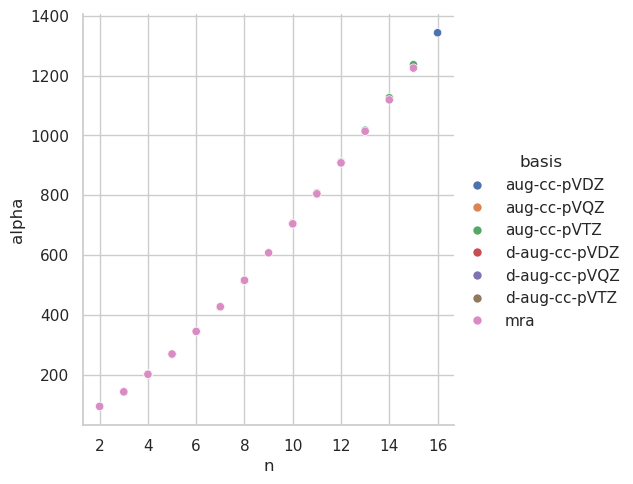

In [20]:
alpha_ijk = alpha_data.pivot_table(
    index=["n", "basis", "omega",'molecule'],
    columns="ij",
    values="alpha",
)


def compute_a0(x):
    return 1 / 3.0 * (x[0][0] + x[1][1] + x[2][2])


a0 = alpha_ijk.apply(lambda x: compute_a0(np.array(x).reshape(3, 3)), axis=1)
a0.name = "alpha"
a0 = a0.reset_index()
import seaborn as sns
sns.set_theme(style="whitegrid")

sns.relplot(
    data=a0.query('omega==0'),
    x="n",
    y="alpha",
    hue="basis",
    kind="scatter",
    facet_kws={"sharey": False, "sharex": True},
)
a0

In [21]:
a0_path = csv_path / "alpha_0.csv"
a0_error_path = csv_path / "alpha_0_error.csv"
a0
alpha_0_error = analysis.MRAComparedBasisDF(
    a0,
    ["n", "omega"],
    ["alpha"],
    True,
    "mra",
)
alpha_0_error

save_alpha = True
if save_alpha:
    a0.to_csv(a0_path, index=False)
    alpha_0_error.to_csv(a0_error_path, index=False)

['D', 'Q', 'T']
items in new_categories are not the same as in old categories


In [22]:
from utils.beta_tensors import compute_beta_hrs, compute_beta_para
shg_ijk = shg_data.pivot_table(
    index=["Afreq", "Bfreq", "Cfreq", "molecule", "basis", "omega"],
    columns="ijk",
    values="Beta",
)
shg_bhrs = shg_ijk.apply(
    lambda x: compute_beta_hrs(np.array(x).reshape(3, 3, 3)), axis=1
)
shg_bhrs.name = "bhrs"
shg_bpara = shg_ijk.apply(
    lambda x: compute_beta_para(np.array(x).reshape(3, 3, 3)), axis=1
)
shg_bpara.name = "bpara"

shg_ijk["bhrs"] = shg_bhrs
shg_ijk["bpara"] = shg_bpara
shg_ijk = shg_ijk.reset_index()

shg_bhrs = shg_bhrs.reset_index()
shg_bpara = shg_bpara.reset_index()

shg_bhrs_error = analysis.MRAComparedBasisDF(
    shg_bhrs, ["molecule", "omega"], ["bhrs"], True, "mra"
)
shg_bhrs_error

shg_bpara_error = analysis.MRAComparedBasisDF(
    shg_bpara, ["molecule", "omega"], ["bpara"], True, "mra"
)
shg_bpara_error

shg_beta_path = csv_path / "shg_beta.csv"
shg_bhrs_error_path = csv_path / "shg_bhrs_error.csv"
shg_bpara_error_path = csv_path / "shg_bpara_error.csv"

['D', 'T', 'Q']
items in new_categories are not the same as in old categories
['D', 'T', 'Q']
items in new_categories are not the same as in old categories


In [23]:
print(shg_bhrs_error.head())

  molecule  omega  Afreq  Bfreq  Cfreq          basis          bhrs  \
0      n10      0   -0.0    0.0    0.0    aug-cc-pVDZ  31658.547849   
1      n10      0   -0.0    0.0    0.0    aug-cc-pVTZ  31143.039071   
2      n10      0   -0.0    0.0    0.0  d-aug-cc-pVDZ  31505.821246   
3      n10      0   -0.0    0.0    0.0  d-aug-cc-pVTZ  31083.677728   
4      n11      0   -0.0    0.0    0.0    aug-cc-pVDZ  40844.064887   

      bhrs[mra]     bhrsE augmentation polarization mol_system valence  \
0  30522.915903  0.037206          aug            V  First-row       D   
1  30522.915903  0.020317          aug            V  First-row       T   
2  30522.915903  0.032202        d-aug            V  First-row       D   
3  30522.915903  0.018372        d-aug            V  First-row       T   
4  39301.985154  0.039237          aug            V  First-row       D   

            Type  
0    aug-cc-pVnZ  
1    aug-cc-pVnZ  
2  d-aug-cc-pVnZ  
3  d-aug-cc-pVnZ  
4    aug-cc-pVnZ  


[0]
    Afreq  Bfreq  Cfreq molecule          basis  omega         bhrs  n  \
44   -0.0    0.0    0.0       n5    aug-cc-pVDZ      0  6773.003055  5   
45   -0.0    0.0    0.0       n5    aug-cc-pVQZ      0  6576.637777  5   
46   -0.0    0.0    0.0       n5    aug-cc-pVTZ      0  6600.636624  5   
47   -0.0    0.0    0.0       n5  d-aug-cc-pVDZ      0  6699.578690  5   
48   -0.0    0.0    0.0       n5  d-aug-cc-pVQZ      0  6566.768344  5   
49   -0.0    0.0    0.0       n5  d-aug-cc-pVTZ      0  6573.646084  5   
50   -0.0    0.0    0.0       n5            mra      0  6529.920716  5   

         bhrs/n  
44  1354.600611  
45  1315.327555  
46  1320.127325  
47  1339.915738  
48  1313.353669  
49  1314.729217  
50  1305.984143  


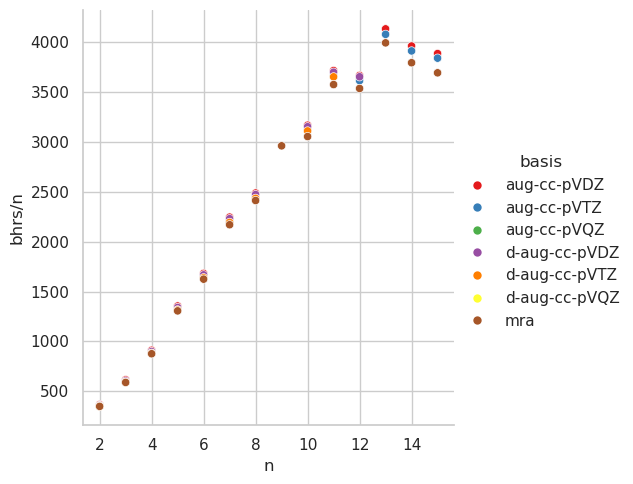

In [24]:
print(shg_bhrs.omega.unique())


shg_bhrs['n']=shg_bhrs['molecule'].apply(lambda x: x.split('n')[-1].split('.')[0])
shg_bhrs['n'] = shg_bhrs['n'].astype(int)
shg_bhrs['bhrs/n'] = shg_bhrs['bhrs']/shg_bhrs['n']
shg_bhrs['basis'] = pd.Categorical(shg_bhrs['basis'], categories=all_basis_sets+['mra'], ordered=True)
print(shg_bhrs.query('omega==0 and molecule=="n5"'))


import seaborn as sns
sns.set(style="whitegrid")
# scatter plot
fig = sns.relplot(
    shg_bhrs.query('omega==0'),
    x="n",
    y="bhrs/n",
    hue='basis',
    palette="Set1"
)

#fig.ax.set_yscale("log")

fig.set_axis_labels("n", "bhrs/n")
fig.set_titles("SHG bhrs")


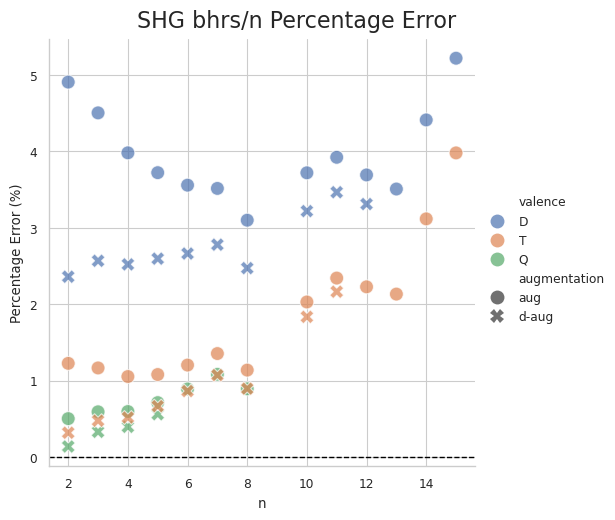

In [25]:
sns.set(style="whitegrid")
sns.set_context("paper", font_scale=1)
import matplotlib.pyplot as plt

shg_bhrs_error['n']=shg_bhrs_error['molecule'].apply(lambda x: x.split('n')[-1].split('.')[0])
shg_bhrs_error['n'] = shg_bhrs_error['n'].astype(int)

shg_bhrs_error['valence']=pd.Categorical(shg_bhrs_error['valence'], categories=['D','T','Q'], ordered=True)
shg_bhrs_error['augmentation']=pd.Categorical(shg_bhrs_error['augmentation'], categories=['aug','d-aug'], ordered=True)

shg_bhrs_error['PE']=shg_bhrs_error['bhrsE']* 100  # convert to percentage error


#order the basis sets
shg_bhrs_error['basis'] = pd.Categorical(shg_bhrs_error['basis'], categories=all_basis_sets, ordered=True)
# scatter plot
fig = sns.relplot(
    shg_bhrs_error.query('omega==0'),
    x="n",
    y="PE",
    hue='valence',
    style='augmentation',
    s=100,
    alpha=0.7,    
    
)
fig.set_titles(col_template="{col_name}Z")
fig.fig.suptitle("SHG bhrs/n Percentage Error", fontsize=16, y=1.03)

fig.set_ylabels("Percentage Error (%)")
fig.set_xlabels("n")

for ax in fig.axes.flat:
    ax.axhline(0, color='black', lw=1, ls='--')


In [25]:
shg_bhrs_error

,molecule,omega,Afreq,Bfreq,Cfreq,basis,bhrs,bhrs[mra],bhrsE,augmentation,polarization,mol_system,valence,Type,n,PE
0,n10,0,-0.0,0.0,0.0,aug-cc-pVDZ,31658.547849,30522.915903,0.037206,aug,V,First-row,D,aug-cc-pVnZ,10,3.720588
1,n10,0,-0.0,0.0,0.0,aug-cc-pVTZ,31143.039071,30522.915903,0.020317,aug,V,First-row,T,aug-cc-pVnZ,10,2.031664
2,n10,0,-0.0,0.0,0.0,d-aug-cc-pVDZ,31505.821246,30522.915903,0.032202,d-aug,V,First-row,D,d-aug-cc-pVnZ,10,3.220221
3,n10,0,-0.0,0.0,0.0,d-aug-cc-pVTZ,31083.677728,30522.915903,0.018372,d-aug,V,First-row,T,d-aug-cc-pVnZ,10,1.837183
4,n11,0,-0.0,0.0,0.0,aug-cc-pVDZ,40844.064887,39301.985154,0.039237,aug,V,First-row,D,aug-cc-pVnZ,11,3.923669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51,n8,0,-0.0,0.0,0.0,aug-cc-pVDZ,19890.921851,19292.631171,0.031011,aug,V,First-row,D,aug-cc-pVnZ,8,3.101136
52,n8,0,-0.0,0.0,0.0,aug-cc-pVQZ,19465.499493,19292.631171,0.008960,aug,V,First-row,Q,aug-cc-pVnZ,8,0.896033
53,n8,0,-0.0,0.0,0.0,aug-cc-pVTZ,19512.734287,19292.631171,0.011409,aug,V,First-row,T,aug-cc-pVnZ,8,1.140866
54,n8,0,-0.0,0.0,0.0,d-aug-cc-pVDZ,19769.992921,19292.631171,0.024743,d-aug,V,First-row,D,d-aug-cc-pVnZ,8,2.474322


In [26]:
shg_table_view=shg_bhrs_error.query('omega==0' ).pivot_table(
    index=['n','valence'],
    columns='augmentation',
    values=['bhrsE'],
    observed=False,
)
shg_table_view.rename(columns={'bhrsE': 'BHRS Error'}, inplace=True)
alpha_0_view = alpha_0_error.query('omega==0').pivot_table(
    index=['n','valence'],
    columns='augmentation',
    values=['alphaE'],
    observed=False,
)

alpha_0_view.rename(columns={'alphaE': 'Alpha Error'}, inplace=True)
pd.concat([alpha_0_view, shg_table_view], axis=1).style.format(
    {
        ("Alpha Error", "aug"): "{:.2f}%",
        ("Alpha Error", "d-aug"): "{:.2f}%",
        ("BHRS Error", "aug"): "{:.2f}%",
        ("BHRS Error", "d-aug"): "{:.2f}%",
    }
).set_caption("Percentage Error of Alpha and Beta_HRS").to_excel(
    csv_path / "shg_alpha_error.xlsx",
    engine="openpyxl",
    index=True,
)




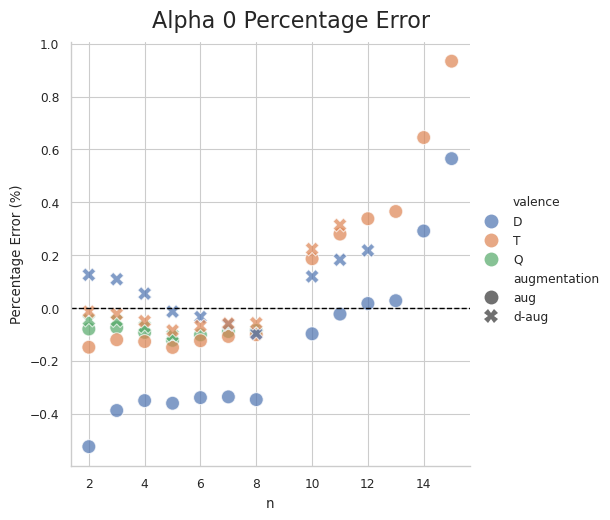

In [27]:
alpha_0_error['n']=alpha_0_error['molecule'].apply(lambda x: x.split('n')[-1].split('.')[0])
alpha_0_error['n'] = alpha_0_error['n'].astype(int)
alpha_0_error['valence']=pd.Categorical(alpha_0_error['valence'], categories=['D','T','Q'], ordered=True)
alpha_0_error['augmentation']=pd.Categorical(alpha_0_error['augmentation'], categories=['aug','d-aug'], ordered=True)
alpha_0_error['PE']=alpha_0_error['alphaE']* 100  # convert to percentage error

g= sns.relplot(
    alpha_0_error.query('omega==0'),
    x="n",
    y="PE",
    hue='valence',
    style="augmentation",
    s=100,
    alpha=0.7,    
    
)
g.fig.suptitle("Alpha 0 Percentage Error", fontsize=16, y=1.03)
g.set_titles(col_template="{col_name}Z")
g.set_ylabels("Percentage Error (%)")
g.set_xlabels("n")
for ax in g.axes.flat:
    ax.axhline(0, color='black', lw=1, ls='--')
# save the data

In [28]:
alpha_0_error

,n,omega,basis,molecule,alpha,alpha[mra],alphaE,augmentation,polarization,mol_system,valence,Type,PE
0,2,0.000,aug-cc-pVDZ,n2,93.275711,93.76814,-0.005252,aug,V,First-row,D,aug-cc-pVnZ,-0.525155
1,2,0.023,aug-cc-pVDZ,n2,93.934892,NaN,NaN,aug,V,First-row,D,aug-cc-pVnZ,NaN
2,2,0.045,aug-cc-pVDZ,n2,96.033201,NaN,NaN,aug,V,First-row,D,aug-cc-pVnZ,NaN
3,2,0.068,aug-cc-pVDZ,n2,100.001103,NaN,NaN,aug,V,First-row,D,aug-cc-pVnZ,NaN
4,2,0.090,aug-cc-pVDZ,n2,106.868388,NaN,NaN,aug,V,First-row,D,aug-cc-pVnZ,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,15,0.015,aug-cc-pVTZ,n15,1263.722404,NaN,NaN,aug,V,First-row,T,aug-cc-pVnZ,NaN
191,15,0.030,aug-cc-pVTZ,n15,1353.952190,NaN,NaN,aug,V,First-row,T,aug-cc-pVnZ,NaN
192,16,0.000,aug-cc-pVDZ,n16,1343.721972,NaN,NaN,aug,V,First-row,D,aug-cc-pVnZ,NaN
193,16,0.015,aug-cc-pVDZ,n16,1372.948275,NaN,NaN,aug,V,First-row,D,aug-cc-pVnZ,NaN


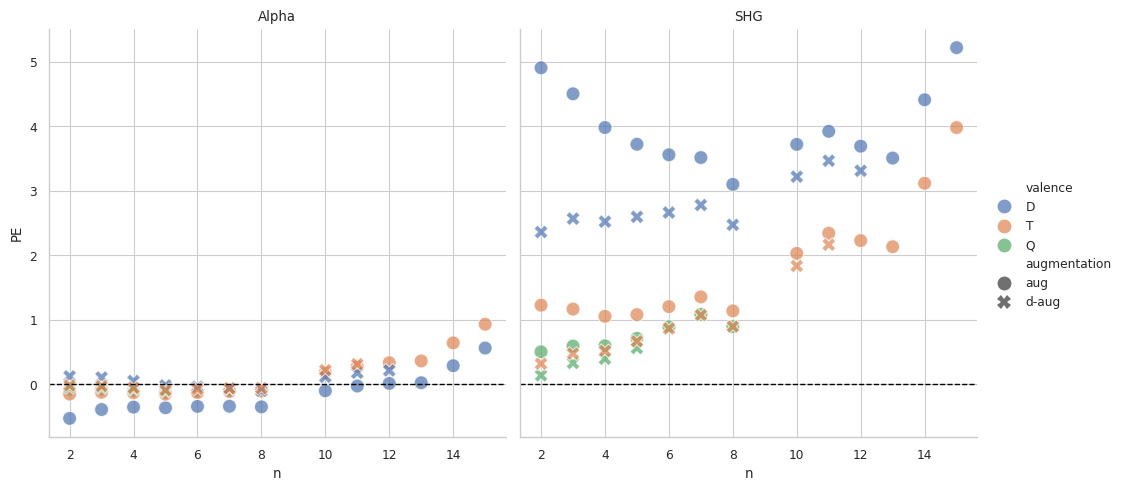

In [28]:
shg_pe=shg_bhrs_error.query('omega==0').set_index(['n','omega','basis','valence','augmentation','polarization','Type'])['PE']
alpha_pe=alpha_0_error.query('omega==0').set_index(['n','omega','basis','valence','augmentation','polarization','Type'])['PE']

shg_pe = shg_pe.reset_index()
shg_pe['measure'] = 'SHG'
alpha_pe = alpha_pe.reset_index()
alpha_pe['measure'] = 'Alpha'



pe_data = pd.concat([shg_pe, alpha_pe], axis=0)
pe_data['measure'] = pd.Categorical(pe_data['measure'], categories=['Alpha', 'SHG'], ordered=True)
pe_data = pe_data.reset_index()
pe_data

g= sns.relplot(
    pe_data,
    x="n",
    y="PE",
    col="measure",
    hue='valence',
    style="augmentation",
    s=100,
    alpha=0.7,    
)
for ax in g.axes.flat:
    ax.axhline(0, color='black', lw=1, ls='--')

g.set_titles(col_template="{col_name}")



In [29]:
eope_ijk = eope_data.pivot_table(
    index=["Afreq", "Bfreq", "Cfreq", "molecule", "basis", "omega"],
    columns="ijk",
    values="Beta",
)
eope_bhrs = eope_ijk.apply(
    lambda x: compute_beta_hrs(np.array(x).reshape(3, 3, 3)), axis=1
)
eope_bhrs.name = "bhrs"
eope_bpara = eope_ijk.apply(
    lambda x: compute_beta_para(np.array(x).reshape(3, 3, 3)), axis=1
)
eope_bpara.name = "bpara"

eope_ijk["bhrs"] = eope_bhrs
eope_ijk["bpara"] = eope_bpara
eope_ijk = eope_ijk.reset_index()

eope_bhrs = eope_bhrs.reset_index()
eope_bpara = eope_bpara.reset_index()

eope_bhrs_error = analysis.MRAComparedBasisDF(
    eope_bhrs, ["molecule", "omega"], ["bhrs"], True, "mra-high"
)

eope_bpara_error = analysis.MRAComparedBasisDF(
    eope_bpara, ["molecule", "omega"], ["bpara"], True, "mra-high"
)

eope_beta_path = csv_path / "eope_beta.csv"
eope_bhrs_error_path = csv_path / "eope_bhrs_error.csv"
eope_bpara_error_path = csv_path / "eope_bpara_error.csv"

['D', 'T', 'Q']
items in new_categories are not the same as in old categories
['D', 'T', 'Q']
items in new_categories are not the same as in old categories


In [65]:
shg_ijk.to_csv(shg_beta_path, index=False)
shg_bhrs_error.to_csv(shg_bhrs_error_path, index=False)
shg_bpara_error.to_csv(shg_bpara_error_path, index=False)

eope_ijk.to_csv(eope_beta_path, index=False)
eope_bhrs_error.to_csv(eope_bhrs_error_path, index=False)
eope_bpara_error.to_csv(eope_bpara_error_path, index=False)

In [66]:
alpha_0_error.query('omega==0 and basis=="d-aug-cc-pVQZ"').loc[:, ['molecule', 'alpha', 'alpha[mra]','PE' ]].sort_values(by='alpha').to_clipboard()

In [67]:
basis_data.beta.molecule.unique()
mol_list
mol_converged={}
for mol in mol_list:
    mol_converged[mol] = {}
    for basis in all_basis_sets:
        mol_converged[mol][basis] = basis_data.beta.query(
            'molecule==@mol and basis==@basis'
        ).shape[0] > 0

basis_complete_table=pd.DataFrame(mol_converged).T
mra_complete = {}
for mol in mol_list:
    mra_complete[mol] = {}
    mra_complete[mol]["mra"] = mra_beta.query(
        'molecule==@mol'
    ).shape[0] > 0
mra_complete_table = pd.DataFrame(mra_complete).T
mra_complete_table
basis_complete_table = pd.concat(
    [basis_complete_table, mra_complete_table], axis=1
)
df_style=basis_complete_table.style.format(
    lambda x: "Yes" if x else "No"
)
df_style.background_gradient(
    cmap="Greens", low=0, high=1
).set_properties(
    **{
        "font-size": "12pt",
        "text-align": "center",
        "border": "1px solid black",
    }
).set_table_styles(
    [
        {
            "selector": "th",
            "props": [("font-size", "14pt"), ("text-align", "center")],
        }
    ]
)
df_style.to_excel(
    csv_path / "basis_complete_table.xlsx",
    engine="openpyxl",
    index=True,
    header=True,
)

# make a dictionary

In [68]:
basis_complete_table.to_clipboard(index=True, header=True)

In [69]:
shg_data.query('molecule=="n6" and basis =="mra"').to_clipboard(
    index=False,
    header=True,
    columns=["ijk", "Afreq", "Bfreq", "Cfreq", "Beta"],
)

In [70]:
all_scf.query('molecule=="n6"').to_clipboard(
    index=False,
    header=True,
)

In [37]:
all_scf.to_clipboard(
    index=False,
    header=True,
)

In [38]:
shg_data.query('basis=="mra"').to_clipboard(
    index=False,
    header=True,

)

In [39]:
shg_data.to_clipboard(
    index=False,
    header=True,
    columns=['molecule','omega','basis',"ijk", "Afreq", "Bfreq", "Cfreq", "Beta"],
)

In [71]:
import qcengine as qcng
import qcelemental as qcel
from pathlib import Path
from quantumresponsepro import MADMolecule

def to_qcel(mol):
    """
    Convert a molecule to a QCEngine schema.
    """

    symbols = mol["symbols"]
    geometry = mol["geometry"]
    return qcel.models.Molecule(**{"symbols": symbols, "geometry": mol["geometry"]})
project_name = "NLO"
mol_file_folder=Path("/home/ahurta92/Projects/beta_projects/raw_data/{}/molecules".format(project_name))
mol_files=mol_file_folder.glob("*.mol")

mols={}
for file in mol_files:
    print(file)
    madmol=MADMolecule()
    madmol.from_molfile(file)
    mols[file.stem]=to_qcel(madmol.to_json())

/home/ahurta92/Projects/beta_projects/raw_data/NLO/molecules/n12.mol
/home/ahurta92/Projects/beta_projects/raw_data/NLO/molecules/n5.mol
/home/ahurta92/Projects/beta_projects/raw_data/NLO/molecules/n16.mol
/home/ahurta92/Projects/beta_projects/raw_data/NLO/molecules/n2.mol
/home/ahurta92/Projects/beta_projects/raw_data/NLO/molecules/n9.mol
/home/ahurta92/Projects/beta_projects/raw_data/NLO/molecules/n6.mol
/home/ahurta92/Projects/beta_projects/raw_data/NLO/molecules/n3.mol
/home/ahurta92/Projects/beta_projects/raw_data/NLO/molecules/n4.mol
/home/ahurta92/Projects/beta_projects/raw_data/NLO/molecules/n10.mol
/home/ahurta92/Projects/beta_projects/raw_data/NLO/molecules/n15.mol
/home/ahurta92/Projects/beta_projects/raw_data/NLO/molecules/n8.mol
/home/ahurta92/Projects/beta_projects/raw_data/NLO/molecules/n7.mol
/home/ahurta92/Projects/beta_projects/raw_data/NLO/molecules/n13.mol
/home/ahurta92/Projects/beta_projects/raw_data/NLO/molecules/n11.mol
/home/ahurta92/Projects/beta_projects/raw_

In [72]:
from utils.vis_utils import create_molecule_plot, add_basis_vectors, plot_beta_normals_on_sphere, get_vector_data, build_basis_data, signed_scale_errors

shg_data

,ijk,Afreq,Bfreq,Cfreq,molecule,Beta,basis,omega
0,XXX,-0.0,0.0,0.0,n2,-257.570048,mra,0
1,XXY,-0.0,0.0,0.0,n2,524.468103,mra,0
2,XXZ,-0.0,0.0,0.0,n2,0.000024,mra,0
3,XYX,-0.0,0.0,0.0,n2,524.468103,mra,0
4,XYY,-0.0,0.0,0.0,n2,-686.912441,mra,0
...,...,...,...,...,...,...,...,...
3814,ZYY,-0.0,0.0,0.0,n15,-0.0,aug-cc-pVTZ,0
3818,ZYZ,-0.0,0.0,0.0,n15,-27.869444,aug-cc-pVTZ,0
3822,ZZX,-0.0,0.0,0.0,n15,-2.564543,aug-cc-pVTZ,0
3826,ZZY,-0.0,0.0,0.0,n15,-27.869444,aug-cc-pVTZ,0


In [73]:

from utils.vis_utils import beta_proj, beta_df_to_np, compare_basis_set_errors_dynamic_grid
# sns.set_context("paper")
sns.set_context("paper", font_scale=1.5)
sns.set_style("ticks")
from matplotlib.ticker import FormatStrFormatter

figure_data = Path("../figures/{}".format(project_name))

shg_pivot=shg_data.pivot_table(index=['molecule','basis','omega'],columns='ijk',values='Beta')

shg_pivot


ijk                                    XXX           XXY       XXZ  \
molecule basis         omega                                         
n10      aug-cc-pVDZ   0      -1273.951619   5294.557703       0.0   
         aug-cc-pVTZ   0      -1255.529222   5225.637276       0.0   
         d-aug-cc-pVDZ 0       -1269.70035   5267.031764       0.0   
         d-aug-cc-pVTZ 0      -1253.917687   5213.771231       0.0   
         mra           0      -1254.020713   5205.300442  0.000428   
...                                    ...           ...       ...   
n8       aug-cc-pVTZ   0       -804.441629   3441.354431       0.0   
         d-aug-cc-pVDZ 0       -815.580546   3472.718744       0.0   
         d-aug-cc-pVTZ 0       -803.278807   3431.917111       0.0   
         mra           0       -825.143312    3495.95892   0.00033   
n9       mra           0      20367.511065  20978.973039 -0.000933   

ijk                                    XYX           XYY       XYZ       XZX  \
molecule basis         omega                                                   
n10      aug-cc-pVDZ   0       5294.557703  -19891.58537      -0.0       0.0   
         aug-cc-pVTZ   0       5225.637276 -19623.335737      -0.0       0.0   
         d-aug-cc-pVDZ 0       5267.031764 -19779.429785      -0.0       0.0   
         d-aug-cc-pVTZ 0       5213.771231 -19580.444999      -0.0       0.0   
         mra           0       5205.300442 -19447.940469 -0.001319  0.000428   
...                                    ...           ...       ...       ...   
n8       aug-cc-pVTZ   0       3441.354431 -12812.387598       0.0       0.0   
         d-aug-cc-pVDZ 0       3472.718744 -12924.902798       0.0       0.0   
         d-aug-cc-pVTZ 0       3431.917111 -12778.106347       0.0       0.0   
         mra           0        3495.95892  -12877.69825  -0.00195   0.00033   
n9       mra           0      20978.973039  20305.120347 -0.000831 -0.000933   

ijk                                XZY        XZZ           YXX           YXY  \
molecule basis         omega                                                    
n10      aug-cc-pVDZ   0          -0.0  13.790875   5294.557703  -19891.58537   
         aug-cc-pVTZ   0          -0.0  11.955314   5225.637276 -19623.335737   
         d-aug-cc-pVDZ 0          -0.0  12.185156   5267.031764 -19779.429785   
         d-aug-cc-pVTZ 0          -0.0  11.181014   5213.771231 -19580.444999   
         mra           0     -0.001319  10.793277   5205.297223 -19447.919777   
...                                ...        ...           ...           ...   
n8       aug-cc-pVTZ   0           0.0  12.993302   3441.354431 -12812.387598   
         d-aug-cc-pVDZ 0           0.0   13.05915   3472.718744 -12924.902798   
         d-aug-cc-pVTZ 0           0.0  12.139464   3431.917111 -12778.106347   
         mra           0      -0.00195  11.888059   3495.958082  -12877.69477   
n9       mra           0     -0.000831 -29.353374  20978.976028  20305.122324   

ijk                                YXZ           YYX           YYY       YYZ  \
molecule basis         omega                                                   
n10      aug-cc-pVDZ   0          -0.0  -19891.58537  64820.423259       0.0   
         aug-cc-pVTZ   0          -0.0 -19623.335737  63700.067244       0.0   
         d-aug-cc-pVDZ 0          -0.0 -19779.429785  64525.756014       0.0   
         d-aug-cc-pVTZ 0          -0.0 -19580.444999  63586.063007       0.0   
         mra           0     -0.001321 -19447.919777  62170.133465  0.005147   
...                                ...           ...           ...       ...   
n8       aug-cc-pVTZ   0           0.0 -12812.387598  39306.868629      -0.0   
         d-aug-cc-pVDZ 0           0.0 -12924.902798  39892.491357      -0.0   
         d-aug-cc-pVTZ 0           0.0 -12778.106347  39217.868095      -0.0   
         mra           0      -0.00195  -12877.69477   38585.82732  0.009928   
n9       mra           0     -0.00

In [74]:

basis1=['aug-cc-pVDZ','aug-cc-pVTZ','d-aug-cc-pVTZ']
mol_analysis_list=['n2','n3','n4','n5','n6','n7','n8','n9','n10','n11','n12','n13','n14','n15']
for mol in mol_analysis_list:
    basis=basis1
    
    
    try:
        p=compare_basis_set_errors_dynamic_grid(
            mol=mol,
            omega=0,
            shg_pivot=shg_pivot,
            mols=mols,
            reference_basis="mra",
            other_bases=basis,# plot all except the last
            epsilon=0.05,
            max_cols=4,
            basis_cmap="CET_D1A"

        )
    
        cam_positions={}
        cam_positions['H2O']= [1.0, 0.5, 0.5]
        cam_positions['SO2']=[1.0, 0.5, 0.5]
        cam_positions['CH3SH']=[1.0, 0.5, 0.5]
        cam_positions['CH3OH']=[1.0, 0.5, 0.5]
        cam_positions['NaCl']=[1.0, 0.5, 0.5]
        cam_positions['SiH4']=[1.0, 0.5, 0.5]
        cam_positions['CH3Cl']=[1.0, 0.5, 0.5]
    
#        p.camera_position = cam_positions[mol]
        p.camera_position =[1.0, 0.5, 0.5]
    
        p.line_smooth = True
        p.enable_anti_aliasing = True
        p.off_screen = True
    
        p.save_graphic(
            figure_data / "{}_basis_set_errors_first_row.pdf".format(mol),
        )
    except Exception as e:
        print(f"Error processing {mol} with basis {basis}: {e}")
        continue

Max value: 1518.6004968071566, Min value: 10.827445638826063, Max dense value: 1522.0544229570528, Min dense value: 9.045039412568698
Max error: 1, Min error: 0.001


/home/ahurta92/anaconda3/envs/madqc/lib/python3.13/site-packages/pyvista/core/filters/data_set.py:1696: UserWarning: No vector-like data to use for orient. orient will be set to False.
  warnings.warn('No vector-like data to use for orient. orient will be set to False.')


Widget(value='<iframe src="http://localhost:41407/index.html?ui=P_0x7f4763cd42f0_0&reconnect=auto" class="pyvi…

Max value: 3812.55560012579, Min value: 7.997920171986182, Max dense value: 3856.9895982890157, Min dense value: 7.475116831431668
Max error: 1, Min error: 0.001


/home/ahurta92/anaconda3/envs/madqc/lib/python3.13/site-packages/pyvista/core/filters/data_set.py:1696: UserWarning: No vector-like data to use for orient. orient will be set to False.
  warnings.warn('No vector-like data to use for orient. orient will be set to False.')


...

/home/ahurta92/anaconda3/envs/madqc/lib/python3.13/site-packages/pyvista/core/filters/data_set.py:1696: UserWarning: No vector-like data to use for orient. orient will be set to False.
  warnings.warn('No vector-like data to use for orient. orient will be set to False.')


Widget(value='<iframe src="http://localhost:41407/index.html?ui=P_0x7f475ee5c410_9&reconnect=auto" class="pyvi…

Max value: 98532.4261436951, Min value: 20.433130625453572, Max dense value: 98752.12503623271, Min dense value: 3.338198011153849
Max error: 1, Min error: 0.001
Error processing n12 with basis ['aug-cc-pVDZ', 'aug-cc-pVTZ', 'd-aug-cc-pVTZ']: ('n12', 'd-aug-cc-pVTZ', 0)


/home/ahurta92/anaconda3/envs/madqc/lib/python3.13/site-packages/pyvista/core/filters/data_set.py:1696: UserWarning: No vector-like data to use for orient. orient will be set to False.
  warnings.warn('No vector-like data to use for orient. orient will be set to False.')


Max value: 111838.7810772645, Min value: 20.839995761376173, Max dense value: 112088.12790746543, Min dense value: 2.4775029742401156
Max error: 1, Min error: 0.001
Error processing n13 with basis ['aug-cc-pVDZ', 'aug-cc-pVTZ', 'd-aug-cc-pVTZ']: ('n13', 'd-aug-cc-pVTZ', 0)
Max value: 123051.10775477416, Min value: 8.7759044058756, Max dense value: 123325.44570691489, Min dense value: 1.7789246008338662
Max error: 1, Min error: 0.001
Error processing n14 with basis ['aug-cc-pVDZ', 'aug-cc-pVTZ', 'd-aug-cc-pVTZ']: ('n14', 'd-aug-cc-pVTZ', 0)
Max value: 132777.72618690296, Min value: 16.224439193567513, Max dense value: 133943.180090419, Min dense value: 1.8881982286440435
Max error: 1, Min error: 0.001
Error processing n15 with basis ['aug-cc-pVDZ', 'aug-cc-pVTZ', 'd-aug-cc-pVTZ']: ('n15', 'd-aug-cc-pVTZ', 0)


In [75]:

from utils.vis_utils import rotation_matrix_from_vectors

def basis_set_error_integral_xyz(
    mol, omega, shg_pivot, reference_basis="mra", other_bases=["aug-cc-pVDZ", "aug-cc-pVTZ"],
    n_points=5000
):
    import numpy as np
    import pandas as pd
    import pyvista as pv
    sphere=pv.PolyData(pv.Sphere(radius=1.0, center=(0, 0, 0), theta_resolution=180, phi_resolution=180))


    # Compute MRA field
    ref_tensor = beta_df_to_np(shg_pivot.loc[(mol, reference_basis, omega)])
    norms_ref = np.linalg.norm(ref_tensor, axis=1)
    max_idx = np.argmax(norms_ref)
    beff_mra= np.array([beta_proj(ref_tensor, d) for d in sphere.points])
    norms_mra=np.linalg.norm(beff_mra,axis=1)


    z=[0,0,1]
    max_idx = np.argmax(norms_mra)
    max_vec = beff_mra[max_idx]
    min_idx = np.argmin(norms_mra)

    max_vec = sphere.points[max_idx]
    min_vec = sphere.points[min_idx]
    max_val = norms_mra[max_idx]




    results = []

    for basis in other_bases:
        # Basis field
        tensor = beta_df_to_np(shg_pivot.loc[(mol, basis, omega)])
        basis_eff= np.array([beta_proj(tensor, d) for d in sphere.points])
        norms_basis=np.linalg.norm(basis_eff,axis=1)

        error= (basis_eff - beff_mra)/ max_val 
        norms_error=(norms_basis-norms_mra)/max_val



        
        positive_error = abs(error[norms_error >0])
        negative_error= abs(error[norms_error <0])

        print("postive error",positive_error.shape)
        print("positive error",len(positive_error))
        print("neg error",len(negative_error))


        len_pos=len(positive_error)+1
        len_neg=len(negative_error)+1 

        integral_pos_x= np.sum(positive_error[:,0]) * (4 * np.pi / len_pos)
        integral_pos_y = np.sum(positive_error[:,1]) * (4 * np.pi / len_pos)
        integral_pos_z = np.sum(positive_error[:,2]) * (4 * np.pi / len_pos)
        integral_neg_x= np.sum(negative_error[:,0]) * (4 * np.pi /len_neg )
        integral_neg_y = np.sum(negative_error[:,1]) * (4 * np.pi /len_neg)
        integral_neg_z = np.sum(negative_error[:,2]) * (4 * np.pi /len_neg)
        
        avg_pos_x = integral_pos_x / (4 * np.pi)
        avg_pos_y = integral_pos_y / (4 * np.pi)
        avg_pos_z = integral_pos_z / (4 * np.pi)        
        avg_neg_x = integral_neg_x / (4 * np.pi)
        avg_neg_y = integral_neg_y / (4 * np.pi)
        avg_neg_z = integral_neg_z / (4 * np.pi)


        # error_x= np.abs(error[:, 0])
        # error_y = np.abs(error[:, 1])
        # error_z = np.abs(error[:, 2])
        # sphere_pts=len(sphere.points)
        # integral_x= np.sum(error_x) * (4 * np.pi / sphere_pts) 
        # integral_y = np.sum(error_y) * (4 * np.pi / sphere_pts)
        # integral_z = np.sum(error_z) * (4 * np.pi / sphere_pts)

        results.append({
            "molecule": mol,
            "omega": omega,
            "basis": basis,
            # "x_xy": integral_xy_x,
            # "y_xy": integral_xy_y,
            # "z_xy": integral_xy_z,
            # "x_yz": integral_yz_x,
            # "y_yz": integral_yz_y,
            # "z_yz": integral_yz_z,
            # "x_xz": integral_xz_x,
            # "y_xz": integral_xz_y,      
            # "z_xz": integral_xz_z,
            # 'x_total': integral_x,
            # 'y_total': integral_y,
            # 'z_total': integral_z,
            'R1_+': avg_pos_x,
            'R1_-': avg_neg_x,
            'R2_+': avg_pos_y,
            'R2_-': avg_neg_y,
            'R3_+': avg_pos_z,
            'R3_-': avg_neg_z,
        })

    return pd.DataFrame(results)


In [76]:

basis=['aug-cc-pVDZ', 'aug-cc-pVTZ', 'd-aug-cc-pVTZ']
omegas=[0]
if Path(csv_path/"integral_errors.csv").exists() and False:
    basis_errors = pd.read_csv(csv_path/"integral_errors.csv")
else:
    basis_errors= pd.DataFrame()
    for omega in omegas:
        for mol in shg_data.molecule.unique():
            try:
                basis_error = basis_set_error_integral_xyz(
                    mol=mol,
                    omega=omega,
                    shg_pivot=shg_pivot,
                    reference_basis="mra",
                    other_bases=basis,
                )
                basis_errors = pd.concat([basis_errors, basis_error], ignore_index=True)
            except Exception as e:
                print(f"Error processing {mol} at {omega}: {e}")
                continue
    value_vars=basis_errors.set_index(['molecule', 'omega', 'basis']).columns.tolist()
    data= basis_errors.melt(
        value_vars=value_vars,
        var_name='component',
        value_name='error'
    )


    data['sign']=data.component.str.split('_').str[1]
    data['component']=data.component.str.split('_').str[0]

    data.to_csv(csv_path/"integral_errors.csv")

postive error (27462, 3)
positive error 27462
neg error 4580
postive error (26692, 3)
positive error 26692
neg error 5350
postive error (19100, 3)
positive error 19100
neg error 12942
postive error (27730, 3)
positive error 27730
neg error 4312
postive error (25794, 3)
positive error 25794
neg error 6248
postive error (19008, 3)
positive error 19008
neg error 13034
postive error (28186, 3)
positive error 28186
neg error 3856
postive error (24964, 3)
positive error 24964
neg error 7078
postive error (21060, 3)
positive error 21060
neg error 10982
postive error (28790, 3)
positive error 28790
neg error 3252
postive error (24004, 3)
positive error 24004
neg error 8038
postive error (21194, 3)
positive error 21194
neg error 10848
postive error (28806, 3)
positive error 28806
neg error 3236
postive error (23916, 3)
positive error 23916
neg error 8126
postive error (22206, 3)
positive error 22206
neg error 9836
postive error (28322, 3)
positive error 28322
neg error 3720
postive error (24406

In [77]:
basis_errors

,molecule,omega,basis,R1_+,R1_-,R2_+,R2_-,R3_+,R3_-
0,n2,0,aug-cc-pVDZ,0.007906,0.001634,0.012403,0.002480,0.000969,0.000257
1,n2,0,aug-cc-pVTZ,0.001796,0.000643,0.003579,0.001035,0.000306,0.000119
2,n2,0,d-aug-cc-pVTZ,0.000351,0.000189,0.002038,0.000775,0.000023,0.000010
3,n3,0,aug-cc-pVDZ,0.011353,0.001566,0.007017,0.000911,0.000377,0.000174
4,n3,0,aug-cc-pVTZ,0.003712,0.000713,0.001616,0.000349,0.000083,0.000122
5,n3,0,d-aug-cc-pVTZ,0.002831,0.000462,0.000598,0.000230,0.000027,0.000008
6,n4,0,aug-cc-pVDZ,0.003449,0.000274,0.011362,0.001165,0.000160,0.000129
7,n4,0,aug-cc-pVTZ,0.000606,0.000107,0.003893,0.000451,0.000051,0.000065
8,n4,0,d-aug-cc-pVTZ,0.000161,0.000080,0.002797,0.000369,0.000010,0.000003
9,n5,0,aug-cc-pVDZ,0.009108,0.000914,0.005764,0.000479,0.000083,0.000090


   molecule  omega          basis    component     error short_hand   sign  \
0        n2      0    aug-cc-pVDZ  total_error  0.025649        s-D  error   
1        n2      0    aug-cc-pVTZ  total_error  0.007478        s-T  error   
2        n2      0  d-aug-cc-pVTZ  total_error  0.003387        d-T  error   
3        n3      0    aug-cc-pVDZ  total_error  0.021397        s-D  error   
4        n3      0    aug-cc-pVTZ  total_error  0.006595        s-T  error   
5        n3      0  d-aug-cc-pVTZ  total_error  0.004155        d-T  error   
6        n4      0    aug-cc-pVDZ  total_error  0.016539        s-D  error   
7        n4      0    aug-cc-pVTZ  total_error  0.005172        s-T  error   
8        n4      0  d-aug-cc-pVTZ  total_error  0.003419        d-T  error   
9        n5      0    aug-cc-pVDZ  total_error  0.016437        s-D  error   
10       n5      0    aug-cc-pVTZ  total_error  0.006129        s-T  error   
11       n5      0  d-aug-cc-pVTZ  total_error  0.004899        

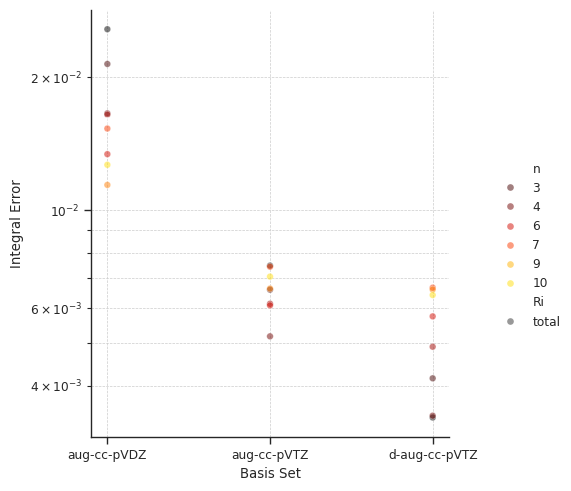

In [78]:

mol1=['n2','n3']
mol2 =['n4','n5','n6','n7','n8']
mol3 =['n9','n10','n11','n12']
m12=[mol1, mol2,mol3]
m12 = [ mols]
short_hand_map={
    "aug-cc-pVDZ": "s-D",
    "aug-cc-pVTZ": "s-T",
    "aug-cc-pVQZ": "s-Q",
    "aug-cc-pCVDZ": "sc-D",
    "aug-cc-pCVTZ": "sc-T",
    "aug-cc-pCVQZ": "sc-Q",
    "d-aug-cc-pVDZ": "d-D",
    "d-aug-cc-pVTZ": "d-T",
    "d-aug-cc-pVQZ": "d-Q",
    "d-aug-cc-pCVDZ": "dc-D",
    "d-aug-cc-pCVTZ": "dc-T",
    "d-aug-cc-pCVQZ": "dc-Q",
}

sns.set_context("paper", font_scale=1.0)

for mi,molsi in enumerate(m12):

    moldata=basis_errors.query("molecule in @molsi").copy()
    moldata['x'] = moldata['R1_+'] + moldata['R1_-']
    moldata['y'] = moldata['R2_+'] + moldata['R2_-']
    moldata['z'] = moldata['R3_+'] + moldata['R3_-']
    total_error = moldata[['x', 'y', 'z']].sum(axis=1)
    moldata['total_error'] = total_error

    data= moldata.melt(
        id_vars=['molecule', 'omega', 'basis'],
        value_vars=['total_error'],
        var_name='component',
        value_name='error'
    )
    reds = sns.color_palette("Reds", 1)
    green=sns.color_palette("Greens", 1)
    blue=sns.color_palette("Blues", 1)

    pal={'R1':'blue','R2':'green','R3':'red'}
    data['short_hand'] = data['basis'].map(short_hand_map)

    # order molecules by mol_analysis_list
    data['molecule'] = pd.Categorical(data['molecule'], categories=molsi, ordered=True)
    markers = {
        '+': '>',
        '-': '<'  }


    data['sign']=data.component.str.split('_').str[1]
    data['Ri']=data['component'].str.split('_').str[0]
    data['sizes']=(data['omega']+1)*10

    # remove n from molecule names
    data['n'] = data['molecule'].str.replace('n', '', regex=False)
    data['n']= data['n'].astype(int)
    print(data)
    sns.set_context("paper", font_scale=1.0)

    sns.set_style("ticks")
    g=sns.relplot(
        data=data,
        x='basis',
        y='error',
        alpha=0.5,
        hue='n',
        style='Ri',
        aspect=1.0,
        palette="cet_fire",
        facet_kws={'sharey': True, 'sharex': True},
        sizes=(150, 250),
    )

    g.set_axis_labels("Basis Set", "Integral Error")
    g.set_titles(col_template="{col_name} ", row_template="{row_name}")
    g.set(yscale='log')

    #l=g.axes[1,0].get_xticklabels()
    
    for ax in g.axes.flat:
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)

    g.tight_layout(w_pad=0.0)
    g.figure.savefig(
        figure_data / "basis_set_error_integral_xyz_mol_analysis{}.png".format(mi+1),
        dpi=300,
        bbox_inches='tight'
    )